<a href="https://colab.research.google.com/github/vikrantyadav11234/DL_-_CNN_Practice/blob/main/DL_standarization_Normalization_Early_Stopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('/content/Social_Network_Ads.csv')

In [ ]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
# (1)feature scaling without data normalization
# (2) Feature scaling with data normalization

In [ ]:
# user ID is just for identification purpose and purchasing is also not depend
# on gender. so we drop these two features. Age and salary are the importannt
# features to predict purchasing. And this is the classification problam bcoz
# bcoz output has catagories whether purchase happens or not.

In [ ]:
## Feature Scaling is a mandatory step

In [ ]:
df=df.iloc[:,2:]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
import seaborn as sns

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

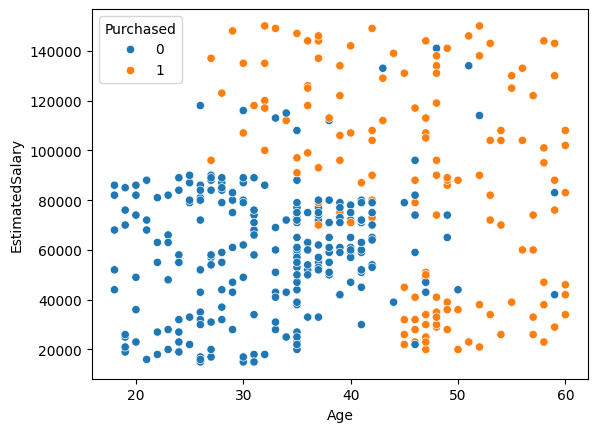

In [ ]:
sns.scatterplot(x=df.iloc[:,0],y=df.iloc[:,1],hue=df.iloc[:,2])

In [ ]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=101)

Building DNN without data normalization

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense


In [ ]:
model=Sequential()
model.add(Dense(units=128,activation='relu',input_dim=2))
model.add(Dense(units=1,activation='sigmoid'))
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 128)               384       
                                                                 
 dense_7 (Dense)             (None, 1)                 129       
                                                                 
Total params: 513 (2.00 KB)
Trainable params: 513 (2.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(X_train,y_train, validation_data=(X_test,y_test),epochs=200)

Epoch 1/200
10/10 [==============================] - 2s 42ms/step - loss: 320.0216 - accuracy: 0.4531 - val_loss: 237.4532 - val_accuracy: 0.3250
Epoch 2/200
10/10 [==============================] - 0s 10ms/step - loss: 163.9162 - accuracy: 0.4844 - val_loss: 194.7681 - val_accuracy: 0.3250
Epoch 3/200
10/10 [==============================] - 0s 9ms/step - loss: 140.4267 - accuracy: 0.5094 - val_loss: 161.7785 - val_accuracy: 0.3250
Epoch 4/200
10/10 [==============================] - 0s 10ms/step - loss: 80.5203 - accuracy: 0.4656 - val_loss: 31.8953 - val_accuracy: 0.6750
Epoch 5/200
10/10 [==============================] - 0s 10ms/step - loss: 72.8216 - accuracy: 0.5469 - val_loss: 52.3253 - val_accuracy: 0.6750
Epoch 6/200
10/10 [==============================] - 0s 10ms/step - loss: 38.9992 - accuracy: 0.5562 - val_loss: 39.8366 - val_accuracy: 0.3250
Epoch 7/200
10/10 [==============================] - 0s 6ms/step - loss: 41.6015 - accuracy: 0.5406 - val_loss: 75.7211 - val_accur

No improvement from first iteration to

---

last iteration

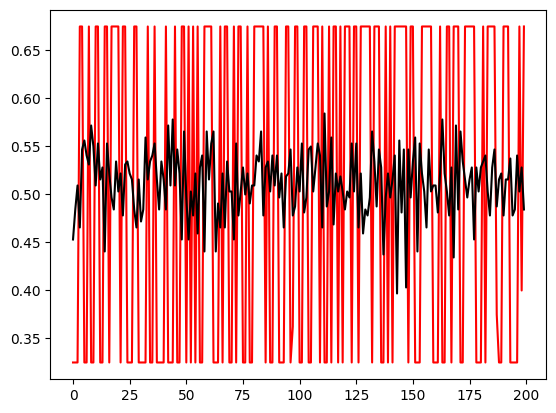

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'],color='red')
plt.plot(history.history['accuracy'],color='black')

In [ ]:
# its a poor model---underfitting problem

NOW WITH FEATURE SCALING
DNN

In [ ]:
## For age we know the range but for Estimated salary we don't know the range
# so standardization is the best scaling technique for this scenario

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_sc=scaler.fit_transform(X_train)
X_test_sc=scaler.transform(X_test)

In [ ]:
model1=Sequential()
model1.add(Dense(units=128,activation='relu',input_dim=2))
model1.add(Dense(units=1,activation='sigmoid'))
model1.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_14 (Dense)            (None, 128)               384       
                                                                 
 dense_15 (Dense)            (None, 1)                 129       
                                                                 
Total params: 513 (2.00 KB)
Trainable params: 513 (2.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
model1.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history1=model1.fit(X_train_sc,y_train, validation_data=(X_test_sc,y_test),epochs=200)

Epoch 1/200
10/10 [==============================] - 1s 21ms/step - loss: 0.6096 - accuracy: 0.8313 - val_loss: 0.5701 - val_accuracy: 0.8125
Epoch 2/200
10/10 [==============================] - 0s 7ms/step - loss: 0.5645 - accuracy: 0.8500 - val_loss: 0.5234 - val_accuracy: 0.8125
Epoch 3/200
10/10 [==============================] - 0s 6ms/step - loss: 0.5240 - accuracy: 0.8469 - val_loss: 0.4836 - val_accuracy: 0.8250
Epoch 4/200
10/10 [==============================] - 0s 7ms/step - loss: 0.4919 - accuracy: 0.8531 - val_loss: 0.4489 - val_accuracy: 0.8250
Epoch 5/200
10/10 [==============================] - 0s 7ms/step - loss: 0.4619 - accuracy: 0.8500 - val_loss: 0.4197 - val_accuracy: 0.8250
Epoch 6/200
10/10 [==============================] - 0s 7ms/step - loss: 0.4376 - accuracy: 0.8562 - val_loss: 0.3942 - val_accuracy: 0.8250
Epoch 7/200
10/10 [==============================] - 0s 6ms/step - loss: 0.4161 - accuracy: 0.8531 - val_loss: 0.3718 - val_accuracy: 0.8500
Epoch 8/200


In [ ]:
## Now accuracy is coming good. Model is good

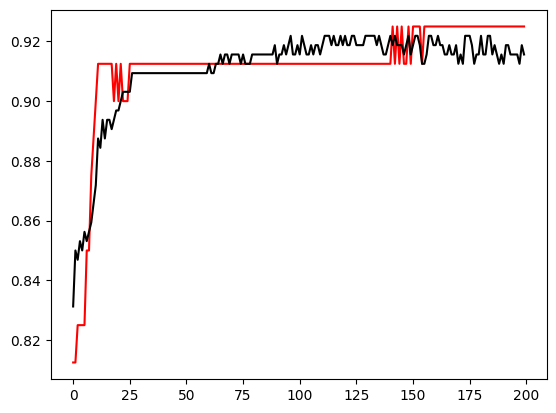

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history1.history['val_accuracy'],color='red')
plt.plot(history1.history['accuracy'],color='black')

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_sc1=scaler.fit_transform(X_train)
X_test_sc1=scaler.fit_transform(X_test)

In [ ]:
model2=Sequential()
model2.add(Dense(units=128,activation='relu',input_dim=2))
model2.add(Dense(units=1,activation='sigmoid'))
model2.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 128)               384       
                                                                 
 dense_17 (Dense)            (None, 1)                 129       
                                                                 
Total params: 513 (2.00 KB)
Trainable params: 513 (2.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
model2.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history2=model2.fit(X_train_sc1,y_train, validation_data=(X_test_sc1,y_test),epochs=200)

Epoch 1/200
10/10 [==============================] - 1s 38ms/step - loss: 0.7403 - accuracy: 0.4187 - val_loss: 0.7147 - val_accuracy: 0.4875
Epoch 2/200
10/10 [==============================] - 0s 7ms/step - loss: 0.6850 - accuracy: 0.5750 - val_loss: 0.6597 - val_accuracy: 0.6500
Epoch 3/200
10/10 [==============================] - 0s 9ms/step - loss: 0.6344 - accuracy: 0.6750 - val_loss: 0.6127 - val_accuracy: 0.7000
Epoch 4/200
10/10 [==============================] - 0s 8ms/step - loss: 0.5928 - accuracy: 0.7656 - val_loss: 0.5697 - val_accuracy: 0.8000
Epoch 5/200
10/10 [==============================] - 0s 8ms/step - loss: 0.5562 - accuracy: 0.7844 - val_loss: 0.5295 - val_accuracy: 0.8125
Epoch 6/200
10/10 [==============================] - 0s 10ms/step - loss: 0.5196 - accuracy: 0.8031 - val_loss: 0.4947 - val_accuracy: 0.8375
Epoch 7/200
10/10 [==============================] - 0s 9ms/step - loss: 0.4888 - accuracy: 0.8156 - val_loss: 0.4615 - val_accuracy: 0.8375
Epoch 8/200

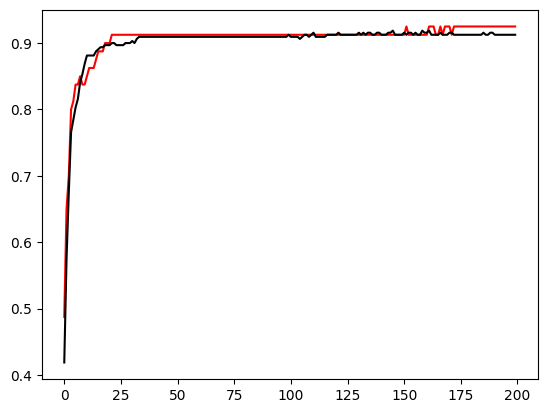

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history2.history['val_accuracy'],color='red')
plt.plot(history2.history['accuracy'],color='black')

# Early Stopping

In [ ]:
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_circles

In [ ]:
from keras.callbacks import EarlyStopping

In [ ]:
x,y = make_circles(n_samples=100, noise=0.1, random_state=1)

In [ ]:
y

array([1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0])

# deep neural network without early stopping

In [ ]:
X_train, X_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [ ]:
model3=Sequential()
model3.add(Dense(units=256,activation='relu',input_dim=2))
model3.add(Dense(1,activation='sigmoid'))
model3.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
history3=model3.fit(X_train,y_train,validation_data=(X_test,y_test), epochs=5000)

Streaming output truncated to the last 5000 lines.
3/3 [==============================] - 0s 30ms/step - loss: 0.2079 - accuracy: 0.9250 - val_loss: 0.4448 - val_accuracy: 0.8500
Epoch 2246/5000
3/3 [==============================] - 0s 33ms/step - loss: 0.2064 - accuracy: 0.9250 - val_loss: 0.4354 - val_accuracy: 0.8500
Epoch 2247/5000
3/3 [==============================] - 0s 27ms/step - loss: 0.2066 - accuracy: 0.9250 - val_loss: 0.4313 - val_accuracy: 0.8500
Epoch 2248/5000
3/3 [==============================] - 0s 24ms/step - loss: 0.2064 - accuracy: 0.9375 - val_loss: 0.4315 - val_accuracy: 0.8500
Epoch 2249/5000
3/3 [==============================] - 0s 30ms/step - loss: 0.2073 - accuracy: 0.9250 - val_loss: 0.4336 - val_accuracy: 0.8500
Epoch 2250/5000
3/3 [==============================] - 0s 26ms/step - loss: 0.2065 - accuracy: 0.9250 - val_loss: 0.4309 - val_accuracy: 0.8500
Epoch 2251/5000
3/3 [==============================] - 0s 40ms/step - loss: 0.2067 - accuracy: 0.9250

KeyboardInterrupt: 

# DNN with early stopping

In [ ]:
model4=Sequential()
model4.add(Dense(units=256,activation='relu',input_dim=2))
model4.add(Dense(units=1,activation='sigmoid'))

In [ ]:
callback= EarlyStopping(monitor='val_loss',min_delta=0.00001, patience=50, verbose=1,mode='auto')


In [ ]:
model4.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history4=model4.fit(X_train,y_train,validation_data=(X_test,y_test), epochs=5000,callbacks=callback)

Epoch 1/5000
3/3 [==============================] - 58s 91ms/step - loss: 0.6638 - accuracy: 0.5750 - val_loss: 0.7687 - val_accuracy: 0.3500
Epoch 2/5000
3/3 [==============================] - 0s 17ms/step - loss: 0.6626 - accuracy: 0.5625 - val_loss: 0.7644 - val_accuracy: 0.3500
Epoch 3/5000
3/3 [==============================] - 0s 18ms/step - loss: 0.6615 - accuracy: 0.5750 - val_loss: 0.7657 - val_accuracy: 0.3500
Epoch 4/5000
3/3 [==============================] - 0s 17ms/step - loss: 0.6610 - accuracy: 0.5750 - val_loss: 0.7658 - val_accuracy: 0.3500
Epoch 5/5000
3/3 [==============================] - 0s 16ms/step - loss: 0.6609 - accuracy: 0.5875 - val_loss: 0.7664 - val_accuracy: 0.3500
Epoch 6/5000
3/3 [==============================] - 0s 17ms/step - loss: 0.6600 - accuracy: 0.5875 - val_loss: 0.7680 - val_accuracy: 0.3500
Epoch 7/5000
3/3 [==============================] - 0s 23ms/step - loss: 0.6601 - accuracy: 0.6000 - val_loss: 0.7693 - val_accuracy: 0.3500
Epoch 8/5000

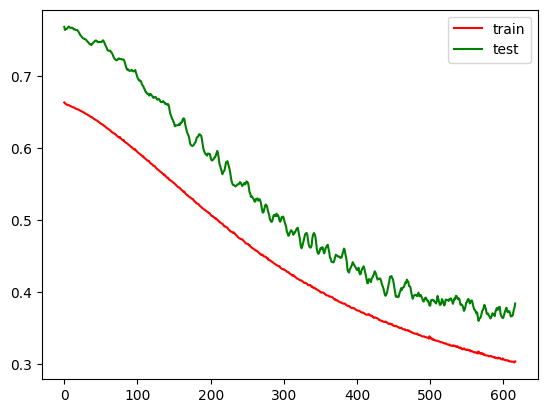

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history4.history['loss'],label='train',color='red')
plt.plot(history4.history['val_loss'],label='test',color='green')
plt.legend()
plt.show()

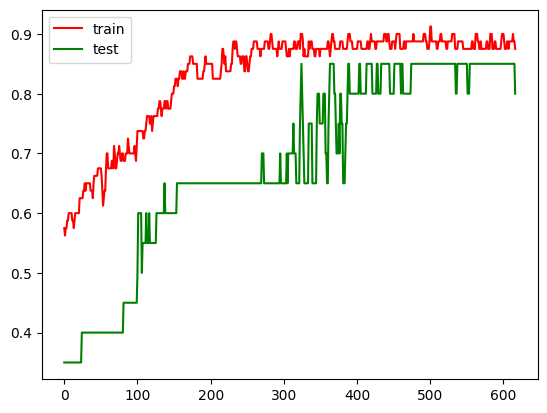

In [ ]:
plt.plot(history4.history['accuracy'],label='train',color='red')
plt.plot(history4.history['val_accuracy'],label='test',color='green')
plt.legend()
plt.show()